# 🔮 Prédiction du Churn Client — TOUIL NET / TECHNOVA
## Notebook complet de Machine Learning

---

**Objectif :** Construire et comparer trois modèles supervisés (Régression Logistique, Random Forest, XGBoost)  
pour prédire si un abonné SaaS va churner (résilier) ou non.

**Pipeline :**
1. Extraction des données depuis PostgreSQL  
2. Construction du dataset enrichi (jointures + features dérivées)  
3. Analyse Exploratoire (EDA)  
4. Préparation des features pour le ML  
5. Entraînement de 3 modèles  
6. Comparaison des performances  
7. Visualisations finales  
8. Rapport automatisé  

---


## 📦 Section 0 — Imports & Configuration

### Description
Cette cellule importe toutes les bibliothèques nécessaires au projet :
- **pandas / numpy** : manipulation et calcul sur les données tabulaires  
- **matplotlib / seaborn** : visualisation des données  
- **scikit-learn** : prétraitement, modèles ML et métriques d'évaluation  
- **xgboost** : algorithme de boosting performant pour la classification  
- **psycopg2** : connecteur Python pour la base de données PostgreSQL  

> ℹ️ Le style `seaborn-v0_8-whitegrid` donne un rendu propre et lisible aux graphiques.


In [5]:
import subprocess, sys

# Mapping : nom pip → nom du module Python à importer
packages = {
    "pandas":          "pandas",
    "numpy":           "numpy",
    "matplotlib":      "matplotlib",
    "seaborn":         "seaborn",
    "scikit-learn":    "sklearn",          # pip install scikit-learn → import sklearn
    "xgboost":         "xgboost",
    "psycopg2-binary": "psycopg2",         # pip install psycopg2-binary → import psycopg2
    "tensorflow":      "tensorflow",
    "scipy":           "scipy",            # nécessaire pour la suppression d'outliers
}

print("🔍 Vérification et installation des dépendances...")
for pip_name, module_name in packages.items():
    try:
        __import__(module_name)
        print(f"   ✅ {pip_name} déjà installé")
    except ImportError:
        print(f"   📦 Installation de {pip_name}...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", pip_name, "--quiet"]
        )
        print(f"   ✅ {pip_name} installé avec succès")

print("\n✅ Toutes les dépendances sont prêtes !")


🔍 Vérification et installation des dépendances...
   ✅ pandas déjà installé
   ✅ numpy déjà installé
   ✅ matplotlib déjà installé
   ✅ seaborn déjà installé
   ✅ scikit-learn déjà installé
   ✅ xgboost déjà installé
   ✅ psycopg2-binary déjà installé
   ✅ tensorflow déjà installé
   ✅ scipy déjà installé

✅ Toutes les dépendances sont prêtes !


In [6]:
import warnings
warnings.filterwarnings('ignore')

# Manipulation de données
import pandas as pd
import numpy as np
from datetime import datetime

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn : prétraitement
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Scikit-learn : modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Scikit-learn : métriques
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# XGBoost
from xgboost import XGBClassifier

# Style des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Tous les imports sont chargés avec succès.")
print("=" * 60)
print("  TOUIL NET — PRÉDICTION DU CHURN SaaS")
print("  Notebook de Machine Learning complet")
print("=" * 60)


✅ Tous les imports sont chargés avec succès.
  TOUIL NET — PRÉDICTION DU CHURN SaaS
  Notebook de Machine Learning complet


## 📥 Section 1 — Extraction des Données (PostgreSQL)

### Description
Cette section se connecte à l'entrepôt de données **PostgreSQL** (`technova_dw`)  
et extrait quatre tables distinctes :

| Table | Contenu | Grain |
|---|---|---|
| `fact_subscriptions` | Abonnements + **cible `est_churn`** | 1 ligne / abonnement |
| `fact_sessions` | Sessions web agrégées | 1 ligne / utilisateur |
| `fact_support` | Tickets support agrégés | 1 ligne / utilisateur |
| `dim_user` | Profil utilisateur | 1 ligne / utilisateur |

### Pourquoi agréger les sessions et tickets ?
Les tables de faits contiennent plusieurs lignes par utilisateur (ex : 10 sessions différentes).  
On les agrège en **statistiques par utilisateur** (moyenne, somme, compte) pour pouvoir  
les joindre avec une seule ligne par utilisateur dans l'étape suivante.

### Fallback (données simulées)
Si PostgreSQL n'est pas disponible, un jeu de données aléatoire de **250 utilisateurs**  
est généré pour permettre de tester tout le pipeline sans base de données.


In [7]:
import psycopg2

# ── Paramètres de connexion ──────────────────────────────────────
POSTGRES_CONFIG = {
    "host":     "localhost",
    "port":     5432,
    "user":     "postgres",
    "password": "mansour",   # ← Modifier si besoin
    "database": "technova_dw",
}

try:
    conn = psycopg2.connect(**POSTGRES_CONFIG)
    print("✅ Connexion PostgreSQL établie")

    # Abonnements (variable cible : est_churn)
    df_subs = pd.read_sql("""
        SELECT user_sk, nom_plan, prix_mensuel_tnd, montant_tnd,
               nb_jours_contrat, mode_paiement, statut,
               est_actif, est_churn, est_renouvellement
        FROM technova_dw.fact_subscriptions
    """, conn)
    print(f"✅ fact_subscriptions : {len(df_subs)} lignes")

    # Sessions agrégées par utilisateur
    df_sessions = pd.read_sql("""
        SELECT user_sk,
               COUNT(*)              AS nb_sessions,
               AVG(duree_secondes)   AS duree_moyenne,
               AVG(pages_visitees)   AS pages_moyenne,
               SUM(bounce)           AS nb_bounces
        FROM technova_dw.fact_sessions
        GROUP BY user_sk
    """, conn)
    print(f"✅ fact_sessions agrégées : {len(df_sessions)} utilisateurs")

    # Tickets support agrégés par utilisateur
    df_support = pd.read_sql("""
        SELECT user_sk,
               COUNT(*)              AS nb_tickets,
               AVG(csat_score)       AS csat_moyen,
               AVG(resolution_heures) AS delai_moyen_h,
               SUM(est_critique)     AS nb_tickets_critiques,
               SUM(est_resolu)       AS nb_tickets_resolus
        FROM technova_dw.fact_support
        GROUP BY user_sk
    """, conn)
    print(f"✅ fact_support agrégées : {len(df_support)} utilisateurs")

    # Profils utilisateurs
    df_users = pd.read_sql("""
        SELECT user_sk, pays, region, sexe, plan, tranche_age,
               est_payant, source_acquisition
        FROM technova_dw.dim_user
        WHERE user_sk > 0
    """, conn)
    print(f"✅ dim_user : {len(df_users)} utilisateurs")

    conn.close()
    print("✅ Connexion fermée proprement.")

except Exception as e:
    print(f"⚠️  PostgreSQL indisponible : {e}")


    np.random.seed(42)
    n = 250

    df_subs = pd.DataFrame({
        'user_sk':          range(1, n+1),
        'nom_plan':         np.random.choice(['Standard', 'Premium', 'Entreprise'], n),
        'prix_mensuel_tnd': np.random.choice([29, 59, 99], n),
        'montant_tnd':      np.random.uniform(100, 1200, n),
        'nb_jours_contrat': np.random.choice([90, 180, 365], n),
        'mode_paiement':    np.random.choice(['Carte', 'Virement', 'PayPal', 'Chèque'], n),
        'statut':           np.random.choice(['Actif', 'Expiré', 'Annulé', 'Remboursé'], n,
                                             p=[0.42, 0.39, 0.12, 0.07]),
        'est_actif': 0, 'est_churn': 0, 'est_renouvellement': 0
    })
    df_subs['est_actif'] = (df_subs['statut'] == 'Actif').astype(int)
    df_subs['est_churn'] = (df_subs['statut'].isin(['Expiré', 'Annulé', 'Remboursé'])).astype(int)

    df_sessions = pd.DataFrame({
        'user_sk':       range(1, n+1),
        'nb_sessions':   np.random.randint(0, 15, n),
        'duree_moyenne': np.random.uniform(5, 60, n),
        'pages_moyenne': np.random.uniform(1, 10, n),
        'nb_bounces':    np.random.randint(0, 5, n)
    })

    df_support = pd.DataFrame({
        'user_sk':               range(1, n+1),
        'nb_tickets':            np.random.randint(0, 8, n),
        'csat_moyen':            np.random.uniform(1, 5, n),
        'delai_moyen_h':         np.random.uniform(10, 500, n),
        'nb_tickets_critiques':  np.random.randint(0, 3, n),
        'nb_tickets_resolus':    np.random.randint(0, 5, n)
    })

    df_users = pd.DataFrame({
        'user_sk':            range(1, n+1),
        'pays':               np.random.choice(['Tunisie', 'France', 'Maroc', 'Algérie'], n),
        'region':             np.random.choice(['Nord', 'Sud', 'Est', 'Ouest'], n),
        'sexe':               np.random.choice(['M', 'F'], n),
        'plan':               np.random.choice(['Standard', 'Premium', 'Entreprise'], n),
        'tranche_age':        np.random.choice(['18-25', '26-35', '36-45', '46+'], n),
        'est_payant':         np.random.choice([0, 1], n),
        'source_acquisition': np.random.choice(['Organique', 'Pub', 'Referral', 'Social'], n)
    })

    print(f"✅ Données simulées générées : {n} utilisateurs")


✅ Connexion PostgreSQL établie
✅ fact_subscriptions : 250 lignes
✅ fact_sessions agrégées : 263 utilisateurs
✅ fact_support agrégées : 195 utilisateurs
✅ dim_user : 300 utilisateurs
✅ Connexion fermée proprement.


## 🔧 Section 2 — Construction du Dataset Enrichi

### Description
On fusionne ici les quatre tables extraites en un **dataset unique** prêt pour le ML.  
La jointure se fait sur la clé `user_sk` (identifiant unique par utilisateur).

### Gestion des valeurs manquantes (NaN)
Certains utilisateurs n'ont pas de sessions enregistrées ou n'ont jamais ouvert de ticket.  
Après la jointure `LEFT JOIN`, ces lignes auront des `NaN`. On les remplace par :
- `0` pour les compteurs (sessions, tickets, bounces…)  
- `3.0` pour le score CSAT (valeur neutre sur une échelle 1-5)

### Features dérivées (Feature Engineering)
Trois nouvelles variables sont créées pour mieux capturer les comportements :

| Feature | Formule | Interprétation |
|---|---|---|
| `taux_resolution` | tickets résolus / total tickets | Qualité du support reçu |
| `ratio_bounce` | bounces / sessions | Engagement faible = fort ratio |
| `engagement_score` | sessions × durée × pages | Score composite d'activité |


In [8]:
# Fusion des 4 tables sur la clé user_sk
df = df_subs.merge(df_sessions, on='user_sk', how='left')
df = df.merge(df_support,  on='user_sk', how='left')
df = df.merge(df_users,    on='user_sk', how='left')

# ── Traitement des valeurs manquantes ───────────────────────────
df['nb_sessions']           = df['nb_sessions'].fillna(0)
df['duree_moyenne']         = df['duree_moyenne'].fillna(0)
df['pages_moyenne']         = df['pages_moyenne'].fillna(0)
df['nb_bounces']            = df['nb_bounces'].fillna(0)
df['nb_tickets']            = df['nb_tickets'].fillna(0)
df['csat_moyen']            = df['csat_moyen'].fillna(3.0)  # Valeur neutre
df['delai_moyen_h']         = df['delai_moyen_h'].fillna(0)
df['nb_tickets_critiques']  = df['nb_tickets_critiques'].fillna(0)
df['nb_tickets_resolus']    = df['nb_tickets_resolus'].fillna(0)

# ── Feature Engineering ─────────────────────────────────────────
# Évite la division par zéro avec .replace(0, 1)
df['taux_resolution'] = df['nb_tickets_resolus'] / df['nb_tickets'].replace(0, 1)
df['ratio_bounce']    = df['nb_bounces'] / df['nb_sessions'].replace(0, 1)
df['engagement_score']= df['nb_sessions'] * df['duree_moyenne'] * df['pages_moyenne']

# ── Sauvegarde ──────────────────────────────────────────────────
df.to_csv('dataset_churn_enrichi.csv', index=False)

print(f"✅ Dataset enrichi : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"✅ Taux de churn global : {df['est_churn'].sum()} churns / {len(df)} total "
      f"({100*df['est_churn'].mean():.1f}%)")
print("✅ Sauvegardé → dataset_churn_enrichi.csv")
df.head()


✅ Dataset enrichi : 250 lignes × 29 colonnes
✅ Taux de churn global : 146 churns / 250 total (58.4%)
✅ Sauvegardé → dataset_churn_enrichi.csv


,user_sk,nom_plan,prix_mensuel_tnd,montant_tnd,nb_jours_contrat,mode_paiement,statut,est_actif,est_churn,est_renouvellement,...,pays,region,sexe,plan,tranche_age,est_payant,source_acquisition,taux_resolution,ratio_bounce,engagement_score
0,37,Premium,99.0,1188.0,365,Carte,Expiré,0,1,0,...,Maroc,Maghreb,Homme,Premium,36-45,1,Facebook,0.0,0.0,40712.333333
1,114,Entreprise,199.0,299.0,365,PayPal,Actif,1,0,0,...,Algérie,Maghreb,Homme,Entreprise,36-45,1,Direct,1.0,0.0,84724.000000
2,257,Standard,49.0,49.0,365,Virement,Expiré,0,1,0,...,Tunisie,Maghreb,Homme,Gratuit,36-45,0,Email,1.0,0.0,0.000000
3,256,Standard,49.0,49.0,365,Carte,Actif,1,0,0,...,Maroc,Maghreb,Homme,Gratuit,46+,0,Referral,0.0,0.0,65566.666667
4,174,Premium,99.0,594.0,365,PayPal,Actif,1,0,0,...,Maroc,Maghreb,Homme,Gratuit,46+,0,LinkedIn,0.5,0.0,244459.285714


## 🧹 Section 2B — Suppression des Outliers

### Description
Les **outliers** (valeurs aberrantes) sont des observations qui s'écartent fortement de la distribution générale. Par exemple : un utilisateur avec 500 sessions alors que la moyenne est de 5, ou un délai de résolution de 10 000 heures.

### Méthode utilisée — Z-Score
Pour chaque colonne numérique on calcule le **Z-Score** = (valeur − moyenne) / écart-type. Toute ligne où au moins une colonne dépasse |Z| > 3 est supprimée (= valeur à plus de 3 écarts-types).

### Pourquoi c'est important
- La Régression Logistique et l'ANN sont **très sensibles** aux outliers
- Un seul utilisateur extrême peut biaiser l'estimation des coefficients
- Random Forest et XGBoost sont plus robustes mais bénéficient quand même du nettoyage


Avant      : 250 lignes
Après      : 244 lignes
Supprimés  : 6 outliers (2.4%)


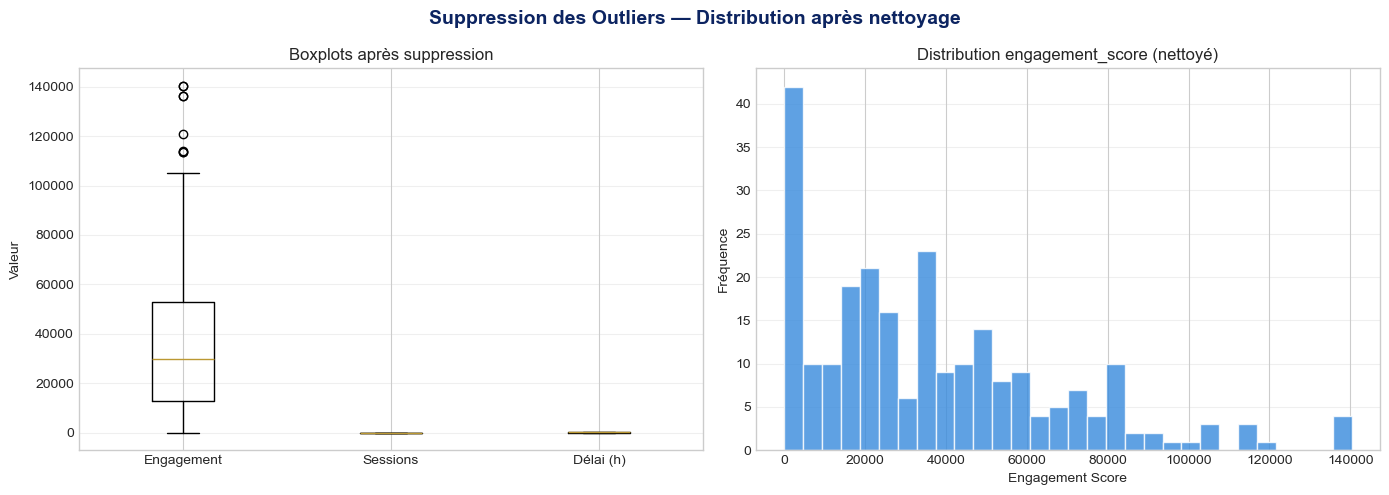

✅ Graphique sauvegardé : 04b_outliers.png


In [9]:
from scipy import stats

# Colonnes numériques à vérifier
cols_outliers = [
    'nb_sessions', 'duree_moyenne', 'pages_moyenne',
    'nb_tickets', 'delai_moyen_h', 'engagement_score'
]

n_avant = len(df)

# Calcul des Z-Scores et filtrage (|Z| < 3)
z_scores = np.abs(stats.zscore(df[cols_outliers].fillna(0)))
masque_valide = (z_scores < 3).all(axis=1)
df = df[masque_valide].reset_index(drop=True)

n_apres = len(df)
n_supprimes = n_avant - n_apres

print(f"Avant      : {n_avant} lignes")
print(f"Après      : {n_apres} lignes")
print(f"Supprimés  : {n_supprimes} outliers ({100*n_supprimes/n_avant:.1f}%)")

# Visualisation avant/après
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Suppression des Outliers — Distribution après nettoyage',
             fontsize=14, fontweight='bold', color='#0C2461')

axes[0].boxplot([df['engagement_score'], df['nb_sessions'], df['delai_moyen_h']],
                labels=['Engagement', 'Sessions', 'Délai (h)'])
axes[0].set_title('Boxplots après suppression')
axes[0].set_ylabel('Valeur')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(df['engagement_score'], bins=30, color='#378ADD',
             edgecolor='white', alpha=0.8)
axes[1].set_title('Distribution engagement_score (nettoyé)')
axes[1].set_xlabel('Engagement Score')
axes[1].set_ylabel('Fréquence')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('04b_outliers.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : 04b_outliers.png")


## 📊 Section 3 — Analyse Exploratoire (EDA)

### Description
L'**EDA (Exploratory Data Analysis)** permet de comprendre les données avant de modéliser.  
Elle répond à des questions comme :
- Quelle est la proportion de churners dans notre dataset ?
- Quel plan tarifaire est le plus exposé au churn ?
- Les utilisateurs qui churnennt ont-ils moins de sessions ?
- Le CSAT (satisfaction client) est-il un bon signal prédictif ?

### Graphiques générés
1. **Distribution du Churn** — Déséquilibre des classes (0 vs 1)
2. **Taux de churn par Plan** — Comparaison Standard / Premium / Entreprise
3. **Sessions vs Churn** — Boîte à moustaches : engagement des churners
4. **CSAT vs Churn** — Satisfaction client des churners vs non-churners
5. **Durée moyenne vs Churn** — Temps passé sur la plateforme
6. **Nb Tickets vs Churn** — Recours au support comme signal de friction

### Matrice de corrélation
Montre les corrélations linéaires entre toutes les variables numériques et la cible `est_churn`.  
Une valeur proche de **+1** indique une forte corrélation positive, **-1** une inverse.


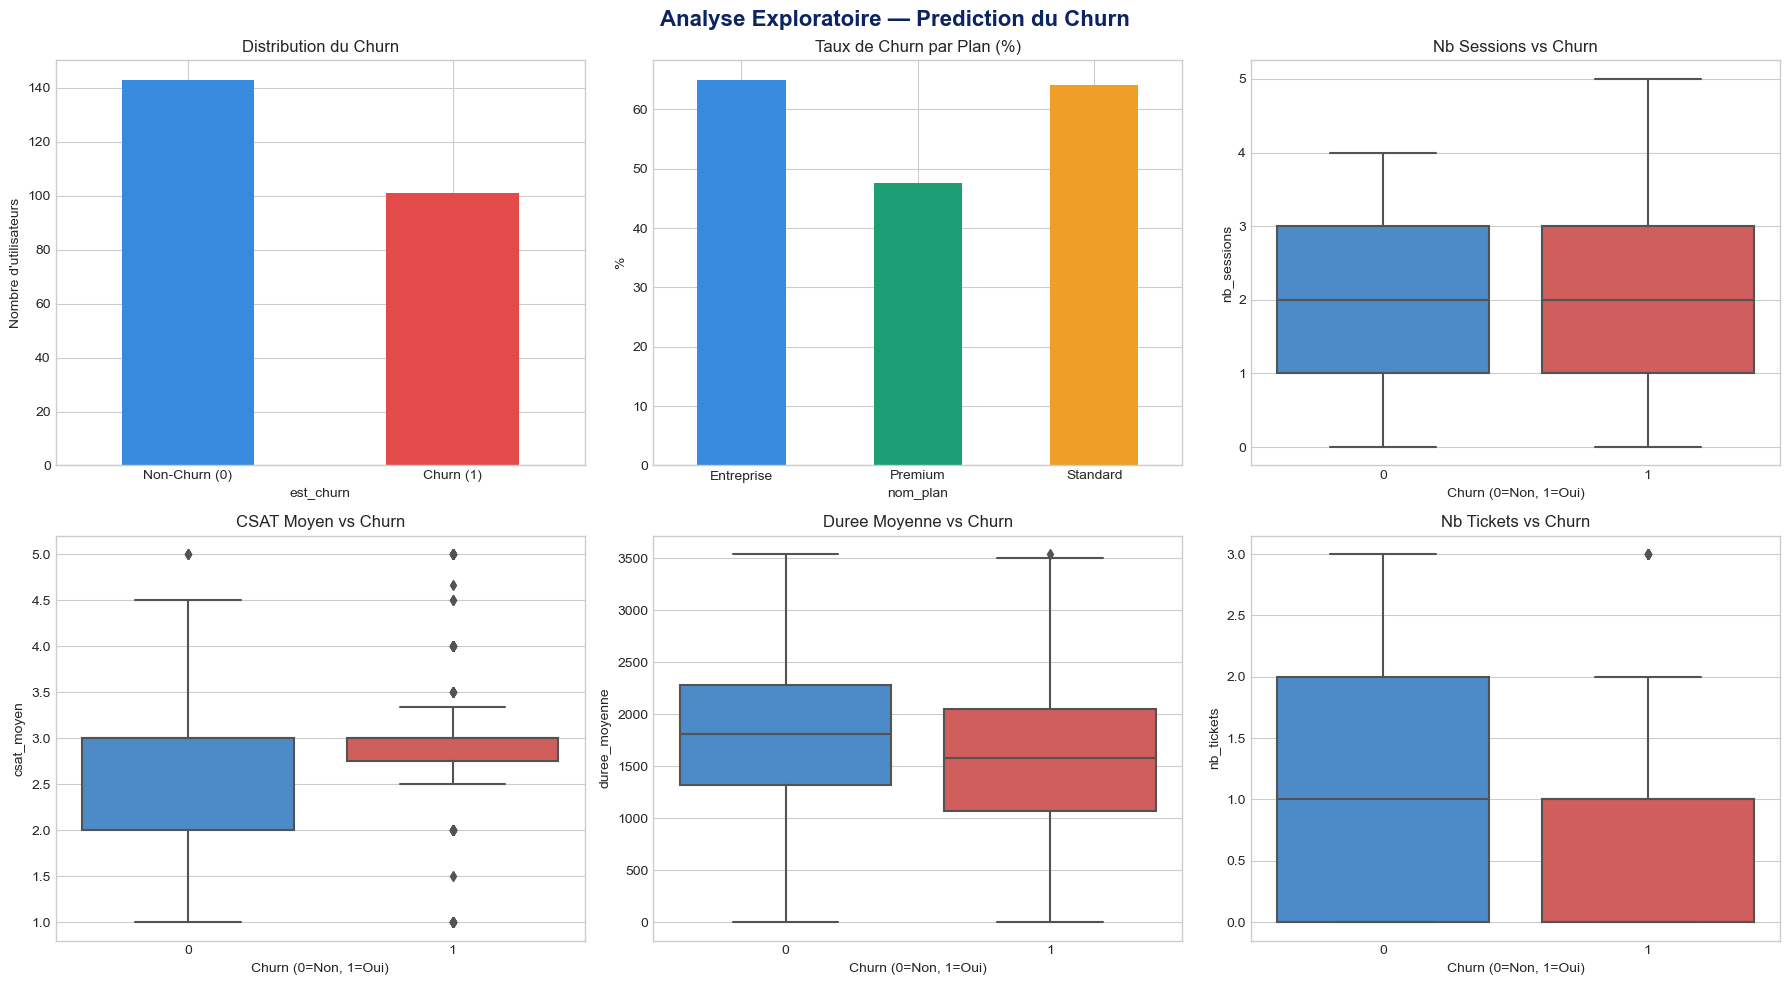

Graphique EDA sauvegarde : 01_eda_churn.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Analyse Exploratoire — Prediction du Churn',
             fontsize=16, fontweight='bold', color='#0C2461')

colors_churn = ['#378ADD', '#E24B4A']

# 1. Distribution du Churn
df['est_churn'].value_counts().plot(kind='bar', ax=axes[0, 0], color=colors_churn)
axes[0, 0].set_title('Distribution du Churn')
axes[0, 0].set_xticklabels(['Non-Churn (0)', 'Churn (1)'], rotation=0)
axes[0, 0].set_ylabel("Nombre d'utilisateurs")

# 2. Taux de churn par plan tarifaire
churn_by_plan = df.groupby('nom_plan')['est_churn'].mean() * 100
churn_by_plan.plot(kind='bar', ax=axes[0, 1],
                   color=['#378ADD', '#1D9E75', '#EF9F27'])
axes[0, 1].set_title('Taux de Churn par Plan (%)')
axes[0, 1].set_ylabel('%')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=0)

# 3. Nb Sessions vs Churn
sns.boxplot(data=df, x='est_churn', y='nb_sessions', ax=axes[0, 2],
            palette=['#378ADD', '#E24B4A'])
axes[0, 2].set_title('Nb Sessions vs Churn')
axes[0, 2].set_xlabel('Churn (0=Non, 1=Oui)')

# 4. CSAT Moyen vs Churn
sns.boxplot(data=df, x='est_churn', y='csat_moyen', ax=axes[1, 0],
            palette=['#378ADD', '#E24B4A'])
axes[1, 0].set_title('CSAT Moyen vs Churn')
axes[1, 0].set_xlabel('Churn (0=Non, 1=Oui)')

# 5. Duree Moyenne vs Churn
sns.boxplot(data=df, x='est_churn', y='duree_moyenne', ax=axes[1, 1],
            palette=['#378ADD', '#E24B4A'])
axes[1, 1].set_title('Duree Moyenne vs Churn')
axes[1, 1].set_xlabel('Churn (0=Non, 1=Oui)')

# 6. Nb Tickets vs Churn
sns.boxplot(data=df, x='est_churn', y='nb_tickets', ax=axes[1, 2],
            palette=['#378ADD', '#E24B4A'])
axes[1, 2].set_title('Nb Tickets vs Churn')
axes[1, 2].set_xlabel('Churn (0=Non, 1=Oui)')

plt.tight_layout()
plt.savefig('01_eda_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique EDA sauvegarde : 01_eda_churn.png")

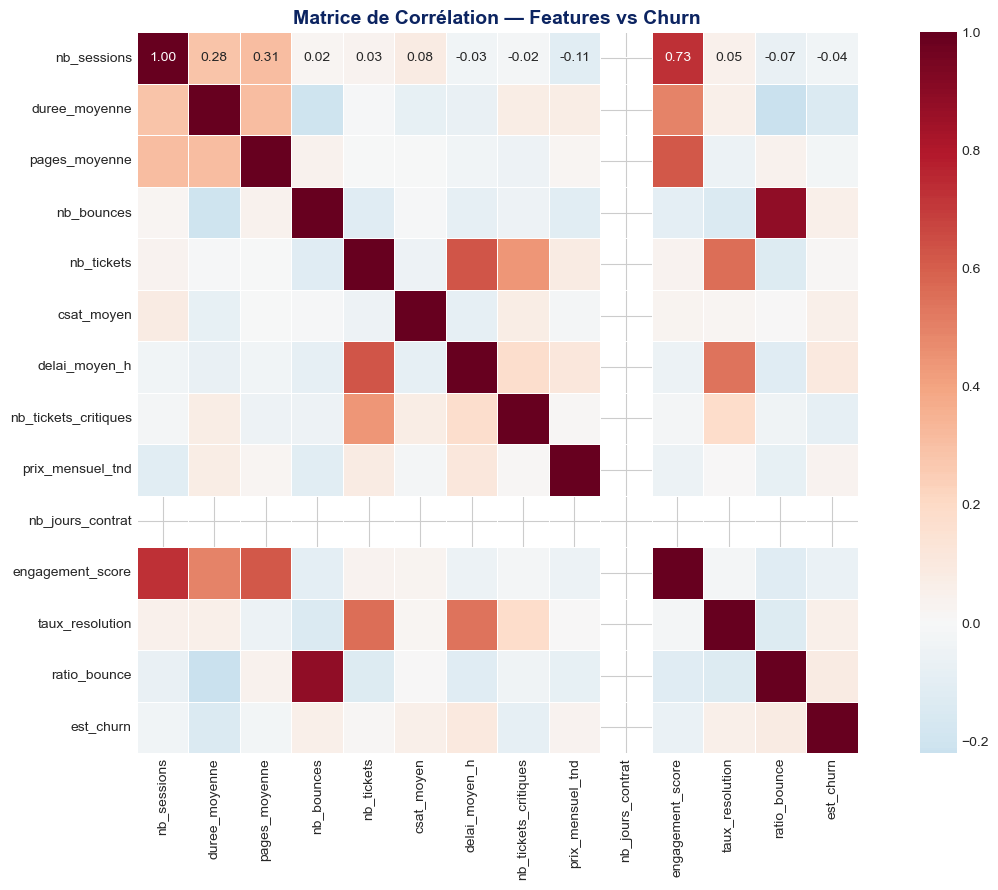

✅ Matrice de corrélation sauvegardée : 02_correlation_matrix.png


In [11]:
# ── Matrice de corrélation ───────────────────────────────────────
features_numeriques = [
    'nb_sessions', 'duree_moyenne', 'pages_moyenne', 'nb_bounces',
    'nb_tickets', 'csat_moyen', 'delai_moyen_h', 'nb_tickets_critiques',
    'prix_mensuel_tnd', 'nb_jours_contrat', 'engagement_score',
    'taux_resolution', 'ratio_bounce', 'est_churn'
]

corr = df[features_numeriques].corr()

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Matrice de Corrélation — Features vs Churn',
             fontsize=14, fontweight='bold', color='#0C2461')
plt.tight_layout()
plt.savefig('02_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Matrice de corrélation sauvegardée : 02_correlation_matrix.png")


## ⚙️ Section 4 — Préparation des Features pour le ML

### Description
Avant d'entraîner un modèle, il faut préparer les données dans un format compatible.  
Cette section effectue trois opérations essentielles :

### 1. Sélection des features
On choisit les colonnes les plus pertinentes comme variables explicatives (X),  
en excluant les identifiants (`user_sk`) et les colonnes liées à la cible.

### 2. Encodage des variables catégorielles
Les modèles ML ne comprennent pas les chaînes de texte (`'Premium'`, `'Carte'`...).  
On utilise `LabelEncoder` pour les convertir en entiers :
- `nom_plan` → `plan_encoded` (ex : Standard=2, Premium=1, Entreprise=0)
- `mode_paiement` → `paiement_encoded`
- `sexe` → `sexe_encoded`

### 3. Normalisation (StandardScaler)
Transforme chaque feature pour qu'elle ait **moyenne = 0** et **écart-type = 1**.  
Indispensable pour la Régression Logistique (sensible aux échelles).

### 4. Split Train / Test (80% / 20%)
- **Train (80%)** : le modèle apprend sur ces données
- **Test (20%)** : on évalue le modèle sur des données jamais vues
- `stratify=y` garantit que la proportion de churners est identique dans les deux splits


In [12]:
# ── Sélection des features numériques ───────────────────────────
feature_cols = [
    'prix_mensuel_tnd', 'nb_jours_contrat',
    'nb_sessions', 'duree_moyenne', 'pages_moyenne', 'nb_bounces',
    'nb_tickets', 'csat_moyen', 'delai_moyen_h', 'nb_tickets_critiques',
    'taux_resolution', 'ratio_bounce', 'engagement_score'
]

# ── Encodage des variables catégorielles ────────────────────────
le_plan = LabelEncoder()
df['plan_encoded'] = le_plan.fit_transform(df['nom_plan'].astype(str))
feature_cols.append('plan_encoded')

le_paiement = LabelEncoder()
df['paiement_encoded'] = le_paiement.fit_transform(df['mode_paiement'].astype(str))
feature_cols.append('paiement_encoded')

if 'sexe' in df.columns and df['sexe'].notna().any():
    le_sexe = LabelEncoder()
    df['sexe_encoded'] = le_sexe.fit_transform(df['sexe'].fillna('M').astype(str))
    feature_cols.append('sexe_encoded')

# ── Matrice X et cible y ─────────────────────────────────────────
X = df[feature_cols].fillna(0)
y = df['est_churn']

# ── Normalisation (StandardScaler) ──────────────────────────────
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# ── Split Train (80%) / Test (20%) stratifié ────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Nombre de features sélectionnées : {len(feature_cols)}")
print(f"   → {feature_cols}")
print(f"\n✅ Split Train/Test :")
print(f"   Train : {len(X_train)} lignes  |  "
      f"Churn={y_train.sum()}  Non-churn={len(y_train)-y_train.sum()}")
print(f"   Test  : {len(X_test)} lignes   |  "
      f"Churn={y_test.sum()}   Non-churn={len(y_test)-y_test.sum()}")


✅ Nombre de features sélectionnées : 16
   → ['prix_mensuel_tnd', 'nb_jours_contrat', 'nb_sessions', 'duree_moyenne', 'pages_moyenne', 'nb_bounces', 'nb_tickets', 'csat_moyen', 'delai_moyen_h', 'nb_tickets_critiques', 'taux_resolution', 'ratio_bounce', 'engagement_score', 'plan_encoded', 'paiement_encoded', 'sexe_encoded']

✅ Split Train/Test :
   Train : 195 lignes  |  Churn=114  Non-churn=81
   Test  : 49 lignes   |  Churn=29   Non-churn=20


## 🤖 Section 5 — Entraînement des 3 Modèles

### Description
Trois algorithmes de classification sont entraînés et évalués :

---

### 1. Régression Logistique
**Principe** : Modèle linéaire qui estime la probabilité d'appartenir à la classe 1 (churn)  
via une fonction sigmoïde appliquée à une combinaison linéaire des features.  
**Avantages** : Simple, interprétable, rapide.  
**Limites** : Ne capture pas les relations non-linéaires.

---

### 2. Random Forest (Forêt Aléatoire)
**Principe** : Ensemble de **100 arbres de décision** entraînés sur des sous-échantillons  
aléatoires. La prédiction finale est un vote majoritaire des arbres.  
**Avantages** : Robuste, gère les non-linéarités, résiste au surapprentissage.

---

### 3. XGBoost (eXtreme Gradient Boosting)
**Principe** : Technique de **boosting** : les arbres sont construits séquentiellement,  
chaque arbre corrigeant les erreurs du précédent.  
**Avantages** : Très performant en pratique, gagnant de nombreuses compétitions ML.

---

### Métriques calculées
| Métrique | Définition |
|---|---|
| **Accuracy** | % de prédictions correctes (toutes classes confondues) |
| **Precision** | Parmi les churns prédits, combien sont réels ? |
| **Recall** | Parmi les churns réels, combien ont été détectés ? |
| **F1-Score** | Moyenne harmonique Precision/Recall (équilibre les deux) |
| **AUC-ROC** | Aire sous la courbe ROC — performance discriminante globale |
| **CV F1** | F1-Score moyen en validation croisée 5-fold (robustesse) |


In [13]:
# ── Définition des 3 modèles ─────────────────────────────────────
models = {
    'Régression Logistique': LogisticRegression(
        max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        random_state=42, eval_metric='logloss', verbosity=0
    )
}

results = {}

for name, model in models.items():
    print(f"\n🔄 Entraînement : {name}...")

    # Entraînement sur le jeu d'entraînement
    model.fit(X_train, y_train)

    # Prédictions sur le jeu de test
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]  # Probabilité de churn

    # Calcul des métriques
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_proba)

    # Validation croisée 5-fold (robustesse du modèle)
    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='f1')

    # Stockage des résultats
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_proba': y_proba,
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'f1': f1, 'auc': auc,
        'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()
    }

    print(f"   Accuracy  : {acc:.4f}")
    print(f"   Precision : {prec:.4f}")
    print(f"   Recall    : {rec:.4f}")
    print(f"   F1-Score  : {f1:.4f}")
    print(f"   AUC-ROC   : {auc:.4f}")
    print(f"   CV F1     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("\n✅ Entraînement des 3 modèles terminé.")



🔄 Entraînement : Régression Logistique...
   Accuracy  : 0.5918
   Precision : 0.6154
   Recall    : 0.8276
   F1-Score  : 0.7059
   AUC-ROC   : 0.5379
   CV F1     : 0.6616 ± 0.0532

🔄 Entraînement : Random Forest...
   Accuracy  : 0.4694
   Precision : 0.5484
   Recall    : 0.5862
   F1-Score  : 0.5667
   AUC-ROC   : 0.4983
   CV F1     : 0.6473 ± 0.0281

🔄 Entraînement : XGBoost...
   Accuracy  : 0.5714
   Precision : 0.6333
   Recall    : 0.6552
   F1-Score  : 0.6441
   AUC-ROC   : 0.5052
   CV F1     : 0.6257 ± 0.0476

✅ Entraînement des 3 modèles terminé.


## 📋 Section 6 — Tableau Comparatif des Modèles

### Description
On regroupe toutes les métriques dans un tableau synthétique pour identifier  
**le meilleur modèle** selon le F1-Score (meilleure métrique pour un problème  
de classification déséquilibrée).

### Pourquoi le F1-Score plutôt que l'Accuracy ?
Dans la prédiction de churn, les classes sont souvent déséquilibrées  
(ex : 58% non-churn, 42% churn). Un modèle qui prédit toujours "non-churn"  
aurait une Accuracy de 58% mais un F1-Score de 0 — ce qui est inutile.  
Le F1-Score pénalise à la fois les faux positifs et les faux négatifs.


In [14]:
# ── Tableau comparatif ───────────────────────────────────────────
comparison = pd.DataFrame({
    name: {
        'Accuracy':          f"{r['accuracy']:.4f}",
        'Precision':         f"{r['precision']:.4f}",
        'Recall':            f"{r['recall']:.4f}",
        'F1-Score':          f"{r['f1']:.4f}",
        'AUC-ROC':           f"{r['auc']:.4f}",
        'CV F1 (mean±std)':  f"{r['cv_mean']:.4f} ± {r['cv_std']:.4f}"
    }
    for name, r in results.items()
})

print("=" * 80)
print("  TABLEAU COMPARATIF DES 3 MODÈLES")
print("=" * 80)
print(comparison.to_string())
print("=" * 80)

# Meilleur modèle selon le F1-Score
best_name = max(results, key=lambda k: results[k]['f1'])
print(f"\n🏆 Meilleur modèle : {best_name}")
print(f"   F1-Score : {results[best_name]['f1']:.4f}")
print(f"   AUC-ROC  : {results[best_name]['auc']:.4f}")

# Sauvegarde du tableau
comparison.to_csv('03_comparaison_modeles.csv')
print("\n✅ Tableau sauvegardé : 03_comparaison_modeles.csv")


  TABLEAU COMPARATIF DES 3 MODÈLES
                 Régression Logistique    Random Forest          XGBoost
Accuracy                        0.5918           0.4694           0.5714
Precision                       0.6154           0.5484           0.6333
Recall                          0.8276           0.5862           0.6552
F1-Score                        0.7059           0.5667           0.6441
AUC-ROC                         0.5379           0.4983           0.5052
CV F1 (mean±std)       0.6616 ± 0.0532  0.6473 ± 0.0281  0.6257 ± 0.0476

🏆 Meilleur modèle : Régression Logistique
   F1-Score : 0.7059
   AUC-ROC  : 0.5379

✅ Tableau sauvegardé : 03_comparaison_modeles.csv


## 📊 Section 7 — Visualisations Finales

### Description
Quatre graphiques sont générés pour analyser et communiquer les résultats :

1. **Courbes ROC** : Comparaison visuelle des trois modèles.  
   L'AUC mesure la capacité du modèle à distinguer les churners des non-churners.  
   Une courbe proche du coin supérieur gauche est idéale.

2. **Matrices de Confusion** : Pour chaque modèle, on voit les prédictions  
   correctes (diagonale) et les erreurs (Faux Positifs et Faux Négatifs).

3. **Importance des Features** : Quelles variables ont le plus influencé les prédictions  
   du meilleur modèle ? Aide à comprendre les leviers du churn.

4. **Comparaison en barres** : Vue synthétique des 5 métriques pour les 3 modèles.


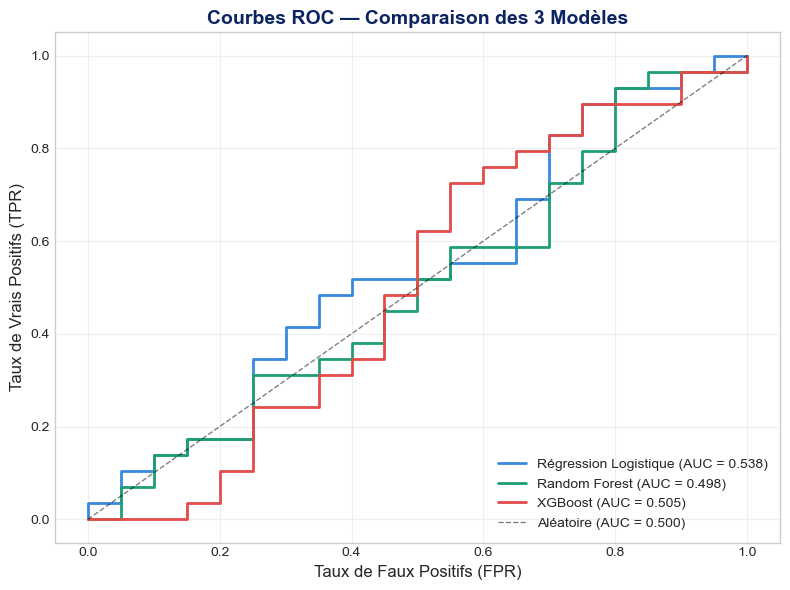

✅ Courbes ROC sauvegardées : 04_courbes_roc.png


In [15]:
colors_models = ['#378ADD', '#1D9E75', '#E24B4A']

# ── 7.1 Courbes ROC ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for (name, r), color in zip(results.items(), colors_models):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{name} (AUC = {r['auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Aléatoire (AUC = 0.500)')
ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
ax.set_title('Courbes ROC — Comparaison des 3 Modèles',
             fontsize=14, fontweight='bold', color='#0C2461')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('04_courbes_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Courbes ROC sauvegardées : 04_courbes_roc.png")


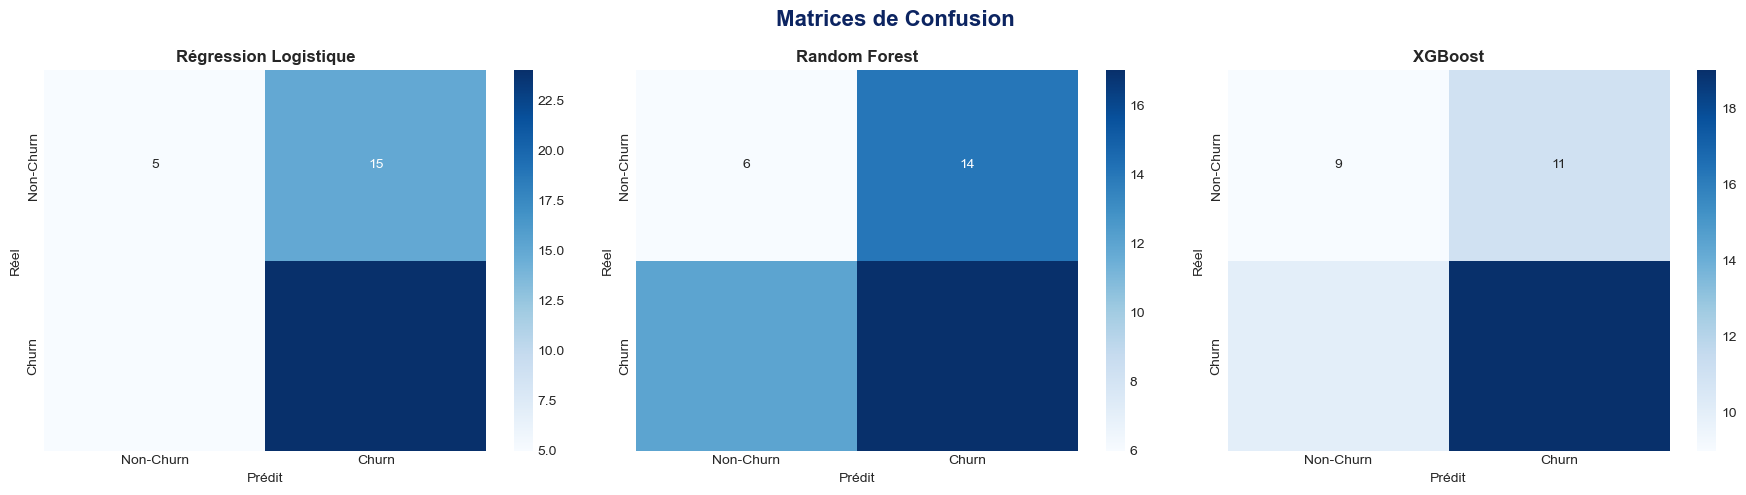

✅ Matrices de confusion sauvegardées : 05_matrices_confusion.png


In [16]:
# ── 7.2 Matrices de Confusion ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrices de Confusion', fontsize=16, fontweight='bold', color='#0C2461')

for (name, r), ax in zip(results.items(), axes):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Churn', 'Churn'],
                yticklabels=['Non-Churn', 'Churn'])
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Réel')
    ax.set_xlabel('Prédit')

plt.tight_layout()
plt.savefig('05_matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Matrices de confusion sauvegardées : 05_matrices_confusion.png")


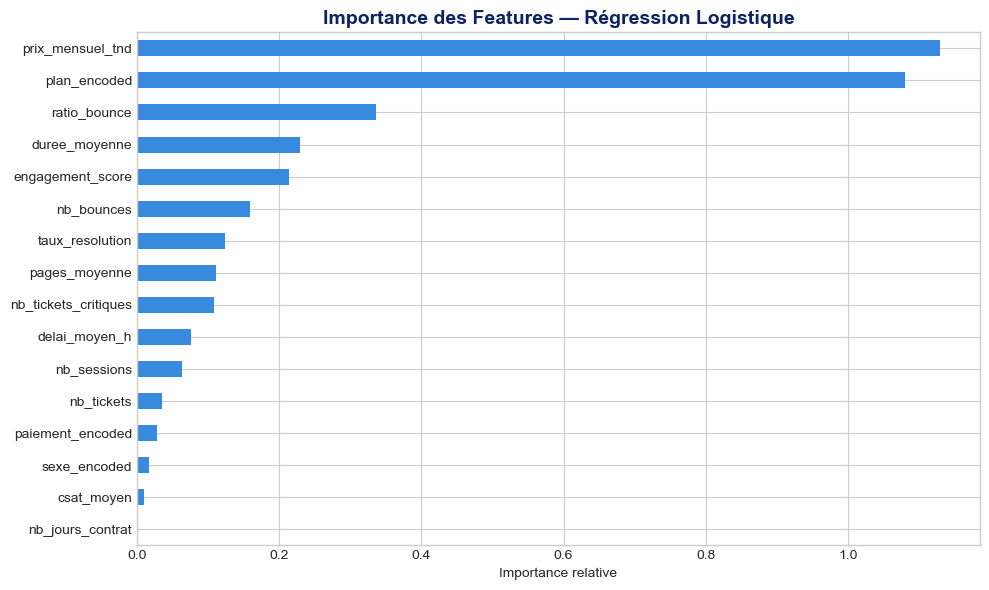

✅ Feature importance sauvegardée : 06_feature_importance.png


In [17]:
# ── 7.3 Importance des Features (meilleur modèle) ────────────────
fig, ax = plt.subplots(figsize=(10, 6))

if best_name == 'Régression Logistique':
    # Coefficients absolus pour la régression logistique
    importances = np.abs(results[best_name]['model'].coef_[0])
else:
    # Feature importances pour les modèles à base d'arbres
    importances = results[best_name]['model'].feature_importances_

feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=ax, color='#378ADD')
ax.set_title(f'Importance des Features — {best_name}',
             fontsize=14, fontweight='bold', color='#0C2461')
ax.set_xlabel('Importance relative')
plt.tight_layout()
plt.savefig('06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Feature importance sauvegardée : 06_feature_importance.png")


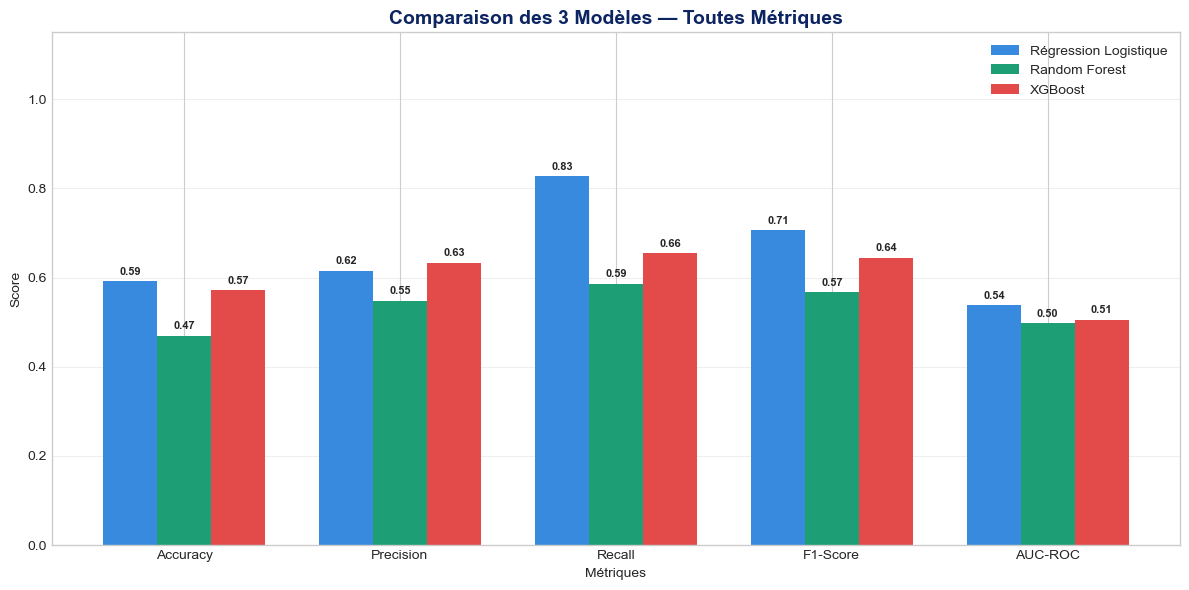

✅ Comparaison barres sauvegardée : 07_comparaison_barres.png


In [18]:
# ── 7.4 Comparaison des métriques en barres groupées ─────────────
fig, ax = plt.subplots(figsize=(12, 6))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x     = np.arange(len(metrics_names))
width = 0.25

for i, (name, r) in enumerate(results.items()):
    values = [r['accuracy'], r['precision'], r['recall'], r['f1'], r['auc']]
    bars   = ax.bar(x + i * width, values, width,
                    label=name, color=colors_models[i])
    # Afficher la valeur au-dessus de chaque barre
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2.,
                bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

ax.set_xlabel('Métriques')
ax.set_ylabel('Score')
ax.set_title('Comparaison des 3 Modèles — Toutes Métriques',
             fontsize=14, fontweight='bold', color='#0C2461')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('07_comparaison_barres.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparaison barres sauvegardée : 07_comparaison_barres.png")


## 🧠 Section 7B — Importation des Librairies ANN

### Description
Un **ANN (Artificial Neural Network)** est un modèle inspiré du cerveau humain, composé de couches de neurones interconnectés. C'est le 4ème modèle qu'on ajoute à la comparaison.

### Composants utilisés
- **Sequential** : architecture linéaire (une couche après l'autre)
- **Dense** : couche entièrement connectée (chaque neurone relié à tous les neurones de la couche suivante)
- **Dropout** : désactive aléatoirement des neurones pour éviter le surapprentissage
- **BatchNormalization** : stabilise et accélère l'entraînement
- **Adam** : optimiseur intelligent qui ajuste automatiquement le pas d'apprentissage
- **EarlyStopping** : arrête l'entraînement quand le modèle cesse de s'améliorer


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("✅ TensorFlow / Keras importés")
print("✅ Couches      : Dense, Dropout, BatchNormalization")
print("✅ Optimizer    : Adam")
print("✅ Callback     : EarlyStopping")


✅ TensorFlow / Keras importés
✅ Couches      : Dense, Dropout, BatchNormalization
✅ Optimizer    : Adam
✅ Callback     : EarlyStopping


## ⚙️ Section 7C — Normalisation pour l'ANN

### Description
On reapplique le **StandardScaler** sur les données nettoyées (sans outliers). L'ANN est encore plus exigeant que la Régression Logistique sur la normalisation : sans elle, les neurones des premières couches saturent (activation à 0 ou 1 en permanence) et le réseau n'apprend rien.

### Formule
Pour chaque variable : `valeur_normalisée = (valeur − moyenne) / écart-type`
Résultat : toutes les variables ont une moyenne ≈ 0 et un écart-type ≈ 1.


In [20]:
# Re-normalisation après suppression des outliers
scaler_ann = StandardScaler()
X_ann_scaled = scaler_ann.fit_transform(X)

# Split Train/Test (même seed que les autres modèles pour comparaison équitable)
X_train_ann, X_test_ann, y_train_ann, y_test_ann = train_test_split(
    X_ann_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Conversion en arrays numpy (requis par Keras)
y_train_ann = np.array(y_train_ann)
y_test_ann  = np.array(y_test_ann)

print(f"✅ X_train_ann : {X_train_ann.shape}")
print(f"✅ X_test_ann  : {X_test_ann.shape}")
print(f"✅ Moyenne features (≈ 0) : {X_ann_scaled.mean():.4f}")
print(f"✅ Std features (≈ 1)     : {X_ann_scaled.std():.4f}")


✅ X_train_ann : (195, 16)
✅ X_test_ann  : (49, 16)
✅ Moyenne features (≈ 0) : -0.0000
✅ Std features (≈ 1)     : 0.9682


## 🏗️ Section 7D — Création du Modèle ANN

### Architecture
```
Entrée (15 features)
   ↓
Couche 1 : 64 neurones (ReLU) + BatchNorm + Dropout 30%
   ↓
Couche 2 : 32 neurones (ReLU) + BatchNorm + Dropout 20%
   ↓
Couche 3 : 16 neurones (ReLU) + Dropout 10%
   ↓
Sortie  : 1 neurone (Sigmoid) → probabilité de churn entre 0 et 1
```

### Choix d'architecture
- **ReLU** dans les couches cachées : rapide et évite le problème du vanishing gradient
- **Sigmoid** en sortie : produit une probabilité (classification binaire)
- **Dropout dégressif** (30% → 20% → 10%) : plus on s'approche de la sortie, moins on perturbe


In [21]:
n_features = X_train_ann.shape[1]

model_ann = Sequential([
    # Couche d'entrée
    Dense(64, activation='relu', input_shape=(n_features,), name='couche_entree'),
    BatchNormalization(name='norm_1'),
    Dropout(0.3, name='dropout_1'),

    # Couche cachée 1
    Dense(32, activation='relu', name='couche_cachee_1'),
    BatchNormalization(name='norm_2'),
    Dropout(0.2, name='dropout_2'),

    # Couche cachée 2
    Dense(16, activation='relu', name='couche_cachee_2'),
    Dropout(0.1, name='dropout_3'),

    # Couche de sortie
    Dense(1, activation='sigmoid', name='couche_sortie')
], name='ANN_Churn_TouilNet')

model_ann.summary()


Model: "ANN_Churn_TouilNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ couche_entree (Dense)           │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ norm_1 (BatchNormalization)     │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ couche_cachee_1 (Dense)         │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ norm_2 (BatchNormalization)     │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ couche_cachee_2 (Dense)         │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ couche_sortie (Dense)           │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 3,905 (15.25 KB)

 Non-trainable params: 192 (768.00 B)

## ⚙️ Section 7E — Compilation du Modèle

### Description
La **compilation** configure comment le réseau va apprendre. Trois paramètres clés :

| Paramètre | Valeur | Rôle |
|---|---|---|
| **Optimizer** | Adam (lr=0.001) | Algorithme qui met à jour les poids à chaque batch |
| **Loss** | binary_crossentropy | Fonction de perte pour classification binaire (0/1) |
| **Metrics** | accuracy | Métrique affichée pendant l'entraînement |

**EarlyStopping** surveille `val_loss` et arrête l'entraînement si elle ne s'améliore plus pendant 10 epochs consécutifs, puis restaure les meilleurs poids.


In [22]:
model_ann.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("✅ Optimizer  : Adam (learning_rate=0.001)")
print("✅ Loss       : binary_crossentropy")
print("✅ Metrics    : accuracy")
print("✅ EarlyStop  : patience=10, restore_best_weights=True")


✅ Optimizer  : Adam (learning_rate=0.001)
✅ Loss       : binary_crossentropy
✅ Metrics    : accuracy
✅ EarlyStop  : patience=10, restore_best_weights=True


## 🔄 Section 7F — Entraînement de l'ANN

### Description
L'ANN s'entraîne pendant maximum **100 epochs** (passages complets sur les données). À chaque epoch :
1. Forward pass : les données traversent le réseau et produisent des prédictions
2. Calcul de la loss : comparaison avec les vraies valeurs
3. Backward pass : ajustement des poids via descente de gradient (Adam)

Le `validation_split=0.2` réserve 20% du train pour valider à chaque epoch (détection du surapprentissage).


In [23]:
history = model_ann.fit(
    X_train_ann, y_train_ann,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print(f"\n✅ Entraînement terminé à l'epoch : {len(history.history['loss'])}")


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 273ms/step - accuracy: 0.5385 - loss: 0.8269 - val_accuracy: 0.6923 - val_loss: 0.6062
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5128 - loss: 0.8134 - val_accuracy: 0.6923 - val_loss: 0.6086
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5449 - loss: 0.8744 - val_accuracy: 0.6923 - val_loss: 0.6113
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5513 - loss: 0.7945 - val_accuracy: 0.6923 - val_loss: 0.6133
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5705 - loss: 0.7370 - val_accuracy: 0.7179 - val_loss: 0.6180
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6090 - loss: 0.6759 - val_accuracy: 0.7692 - val_loss: 0.6231
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5897 - loss: 0.7358 - val_accuracy: 0.7436 - val_loss: 0.6282
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6603 - loss: 0.6397 - val_accuracy: 0.7436 - val_los

## 📊 Section 7G — Évaluation de l'ANN

### Description
On évalue l'ANN sur le **jeu de test** (20% des données jamais vues pendant l'entraînement) avec les mêmes métriques que les 3 autres modèles, pour permettre une comparaison équitable.

Le seuil de décision est fixé à **0.5** : si la probabilité prédite est ≥ 0.5, on classe en churn, sinon en non-churn.


In [24]:
# Prédictions
y_proba_ann = model_ann.predict(X_test_ann).flatten()
y_pred_ann  = (y_proba_ann >= 0.5).astype(int)

# Métriques
acc_ann   = accuracy_score(y_test_ann, y_pred_ann)
prec_ann  = precision_score(y_test_ann, y_pred_ann, zero_division=0)
rec_ann   = recall_score(y_test_ann, y_pred_ann, zero_division=0)
f1_ann    = f1_score(y_test_ann, y_pred_ann, zero_division=0)
auc_ann   = roc_auc_score(y_test_ann, y_proba_ann)

print(f"Accuracy  : {acc_ann:.4f}")
print(f"Precision : {prec_ann:.4f}")
print(f"Recall    : {rec_ann:.4f}")
print(f"F1-Score  : {f1_ann:.4f}")
print(f"AUC-ROC   : {auc_ann:.4f}")

# Ajouter l'ANN aux résultats existants
results['ANN (Réseau de Neurones)'] = {
    'model': model_ann,
    'y_pred': y_pred_ann,
    'y_proba': y_proba_ann,
    'accuracy': acc_ann,
    'precision': prec_ann,
    'recall': rec_ann,
    'f1': f1_ann,
    'auc': auc_ann,
    'cv_mean': 0.0,
    'cv_std': 0.0
}
print("\n✅ ANN ajouté aux résultats globaux")


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 295ms/step
Accuracy  : 0.5714
Precision : 0.5833
Recall    : 0.9655
F1-Score  : 0.7273
AUC-ROC   : 0.4707

✅ ANN ajouté aux résultats globaux


## 📈 Section 7H — Réel vs Prédiction

### Description
Pour chaque modèle, on visualise les 4 cases de la **matrice de confusion** :

| Catégorie | Signification | Impact métier |
|---|---|---|
| **TP** (Vrai Positif) | Churn prédit et réel | ✅ Client à risque correctement identifié |
| **TN** (Vrai Négatif) | Non-churn prédit et réel | ✅ Client fidèle correctement identifié |
| **FP** (Faux Positif) | Prédit churn, mais client resté | ⚠️ Fausse alarme (campagne rétention inutile) |
| **FN** (Faux Négatif) | Prédit qu'il reste, mais a churné | ❌ **Le plus coûteux** : client perdu sans action |

En SaaS, on cherche à **minimiser les FN** (clients perdus) quitte à accepter quelques FP.


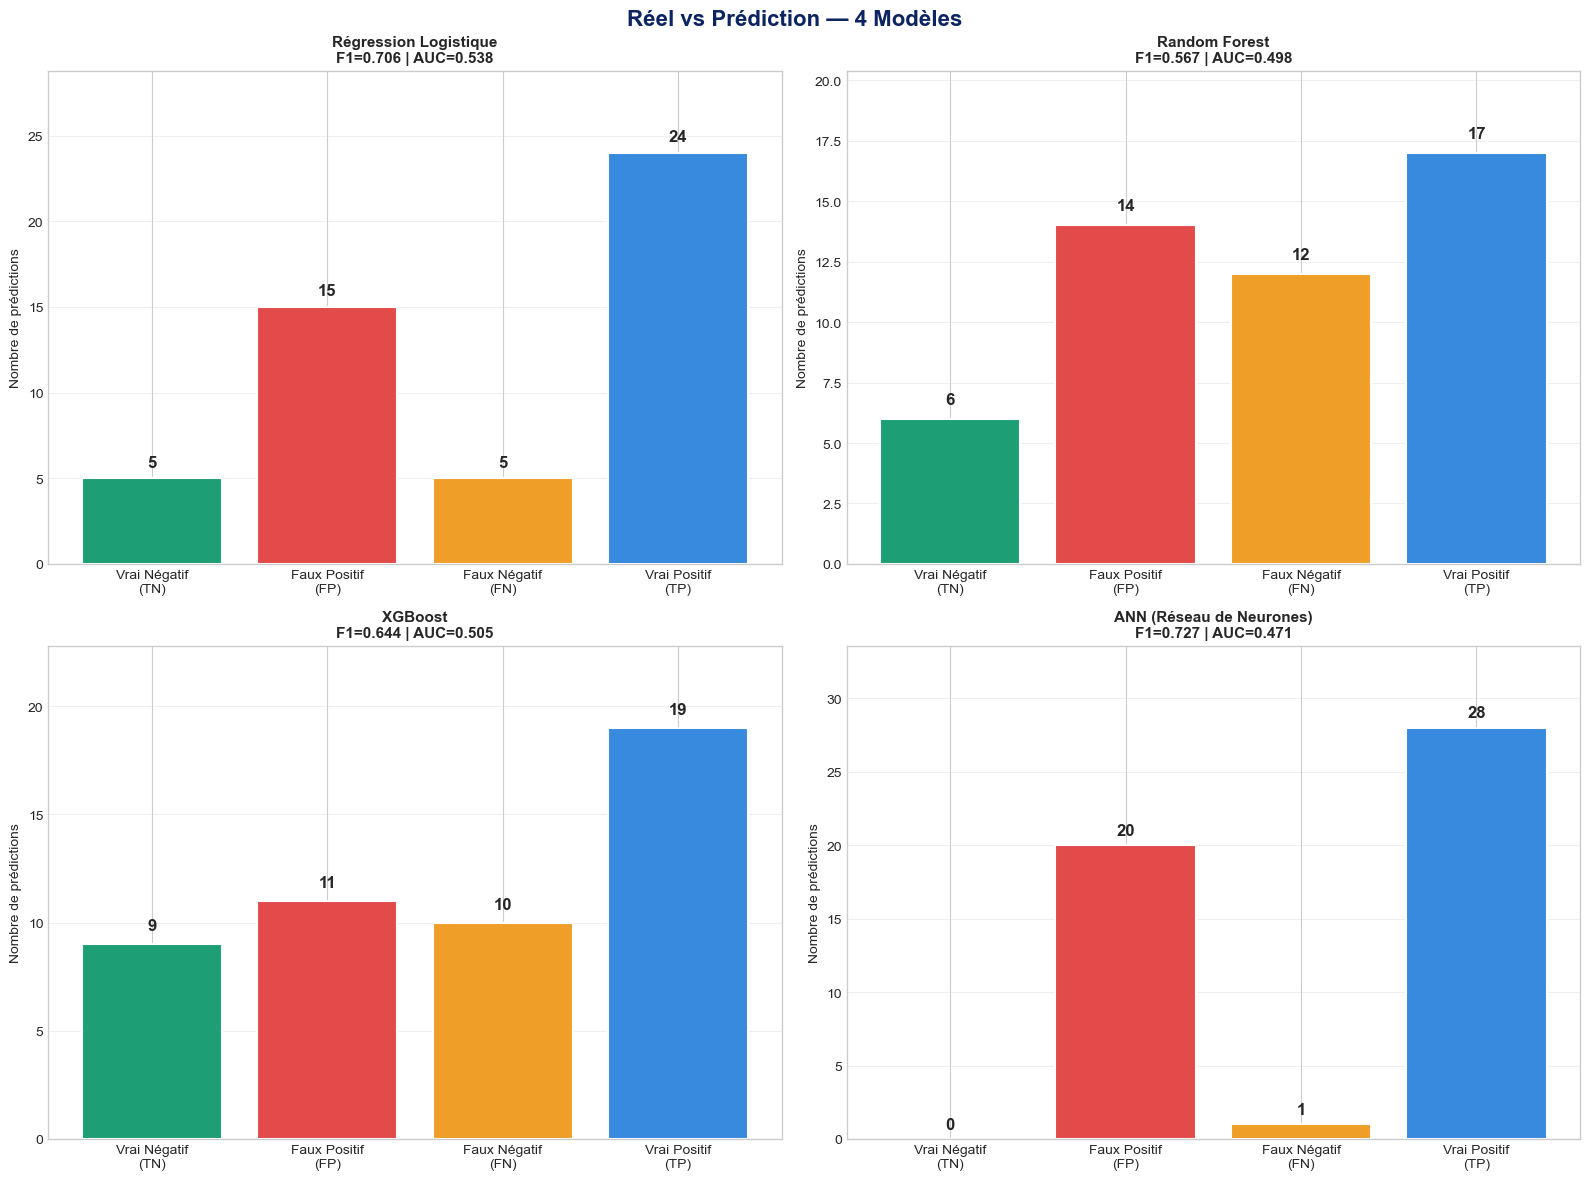

✅ Graphique sauvegardé : 08_reel_vs_prediction.png


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Réel vs Prédiction — 4 Modèles', fontsize=16,
             fontweight='bold', color='#0C2461')

for idx, (name, r) in enumerate(results.items()):
    ax = axes[idx // 2][idx % 2]

    y_reel = y_test_ann if name == 'ANN (Réseau de Neurones)' else y_test
    cm = confusion_matrix(y_reel, r['y_pred'])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

    categories = ['Vrai Négatif\n(TN)', 'Faux Positif\n(FP)',
                  'Faux Négatif\n(FN)', 'Vrai Positif\n(TP)']
    valeurs    = [TN, FP, FN, TP]
    couleurs   = ['#1D9E75', '#E24B4A', '#EF9F27', '#378ADD']

    bars = ax.bar(categories, valeurs, color=couleurs,
                  edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, valeurs):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                str(val), ha='center', va='bottom',
                fontsize=12, fontweight='bold')

    ax.set_title(f'{name}\nF1={r["f1"]:.3f} | AUC={r["auc"]:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Nombre de prédictions')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(valeurs) * 1.2)

plt.tight_layout()
plt.savefig('08_reel_vs_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : 08_reel_vs_prediction.png")


## 📊 Section 7I — Figures Spécifiques à l'ANN

### Description
Trois graphiques permettent de **diagnostiquer la qualité de l'entraînement** :

1. **Courbe de Loss** : les courbes train et val doivent descendre ensemble. Si val_loss remonte → surapprentissage.
2. **Courbe Accuracy** : progression de la précision au fil des epochs.
3. **Distribution des probabilités** : un bon modèle sépare clairement les deux classes (pic vers 0 pour non-churn, pic vers 1 pour churn).


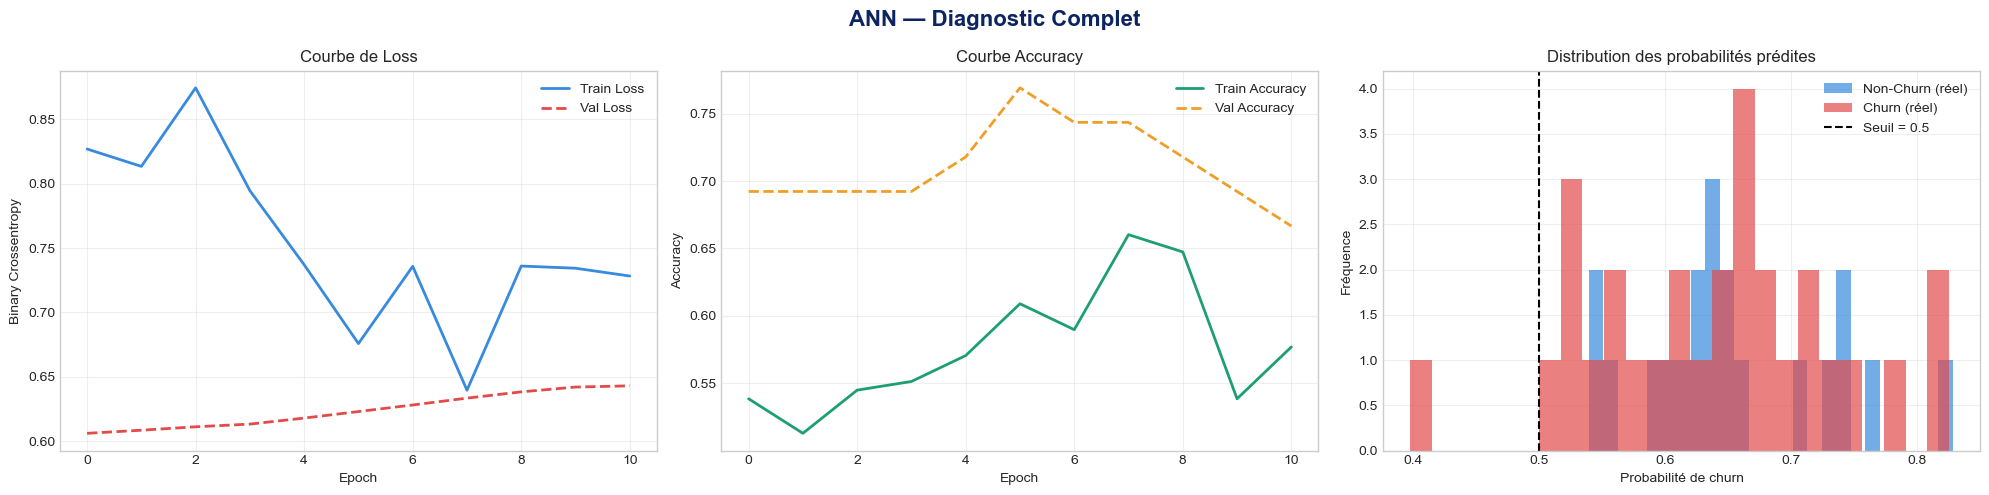

✅ Graphique sauvegardé : 09_ann_figures.png


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('ANN — Diagnostic Complet', fontsize=16,
             fontweight='bold', color='#0C2461')

# 1. Courbe Loss
axes[0].plot(history.history['loss'], color='#378ADD', lw=2, label='Train Loss')
axes[0].plot(history.history['val_loss'], color='#E24B4A', lw=2,
             linestyle='--', label='Val Loss')
axes[0].set_title('Courbe de Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Courbe Accuracy
axes[1].plot(history.history['accuracy'], color='#1D9E75', lw=2, label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], color='#EF9F27', lw=2,
             linestyle='--', label='Val Accuracy')
axes[1].set_title('Courbe Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Distribution des probabilités
axes[2].hist(y_proba_ann[y_test_ann == 0], bins=25, alpha=0.7,
             color='#378ADD', label='Non-Churn (réel)')
axes[2].hist(y_proba_ann[y_test_ann == 1], bins=25, alpha=0.7,
             color='#E24B4A', label='Churn (réel)')
axes[2].axvline(x=0.5, color='black', linestyle='--', lw=1.5, label='Seuil = 0.5')
axes[2].set_title('Distribution des probabilités prédites')
axes[2].set_xlabel('Probabilité de churn')
axes[2].set_ylabel('Fréquence')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('09_ann_figures.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : 09_ann_figures.png")


## 📋 Section 7J — Comparaison Finale des 4 Modèles

### Description
On compare maintenant les **4 modèles ensemble** : Régression Logistique, Random Forest, XGBoost, ANN. Deux visualisations complémentaires :

1. **Tableau récapitulatif** + **barres groupées** : voir d'un coup d'œil quel modèle domine sur chaque métrique
2. **Courbes ROC superposées** : capacité à distinguer churns et non-churns (plus la courbe monte vite, mieux c'est)


In [27]:
# Tableau comparatif final
comparison_finale = pd.DataFrame({
    name: {
        'Accuracy':  f"{r['accuracy']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall':    f"{r['recall']:.4f}",
        'F1-Score':  f"{r['f1']:.4f}",
        'AUC-ROC':   f"{r['auc']:.4f}",
    }
    for name, r in results.items()
})

print("=" * 90)
print("  TABLEAU COMPARATIF FINAL — 4 MODÈLES")
print("=" * 90)
print(comparison_finale.to_string())
print("=" * 90)

comparison_finale.to_csv('comparaison_4modeles.csv')


  TABLEAU COMPARATIF FINAL — 4 MODÈLES
          Régression Logistique Random Forest XGBoost ANN (Réseau de Neurones)
Accuracy                 0.5918        0.4694  0.5714                   0.5714
Precision                0.6154        0.5484  0.6333                   0.5833
Recall                   0.8276        0.5862  0.6552                   0.9655
F1-Score                 0.7059        0.5667  0.6441                   0.7273
AUC-ROC                  0.5379        0.4983  0.5052                   0.4707


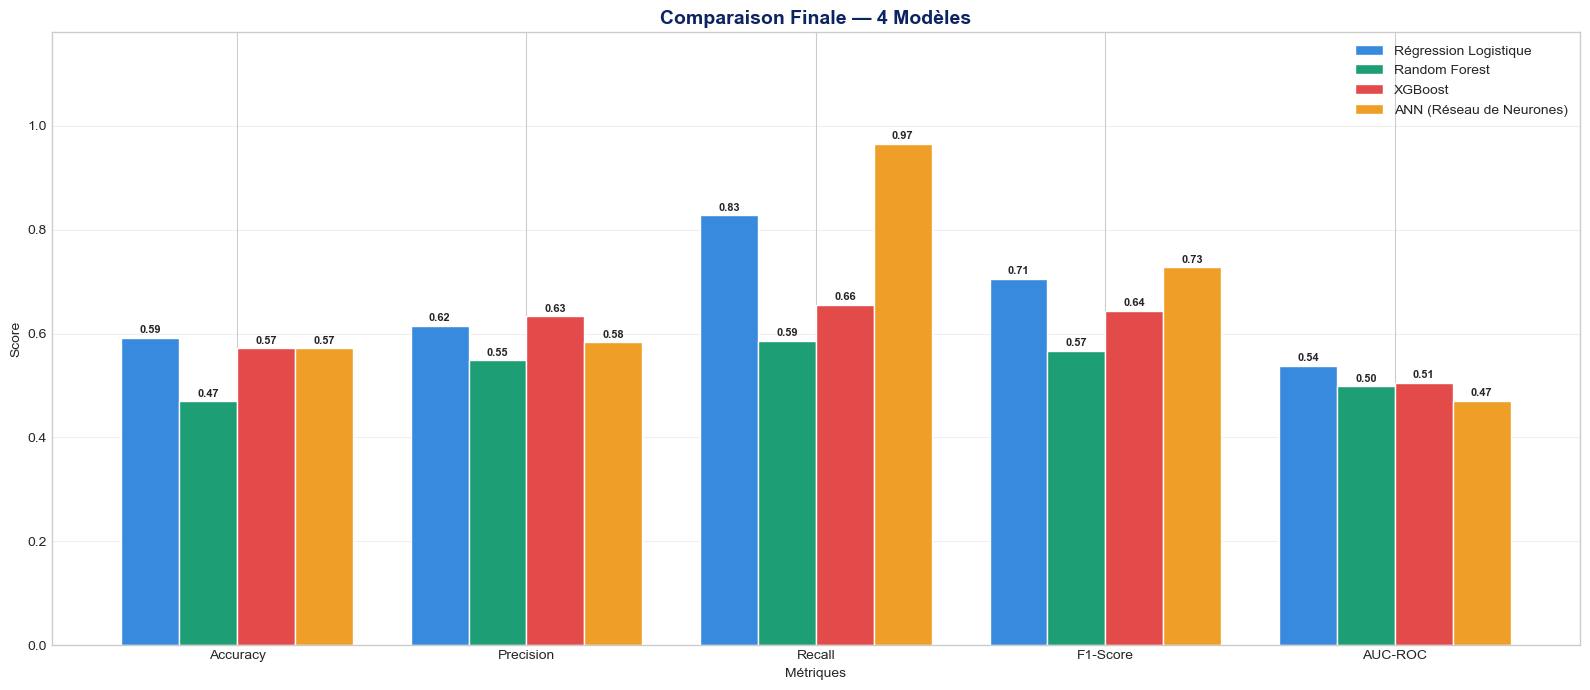

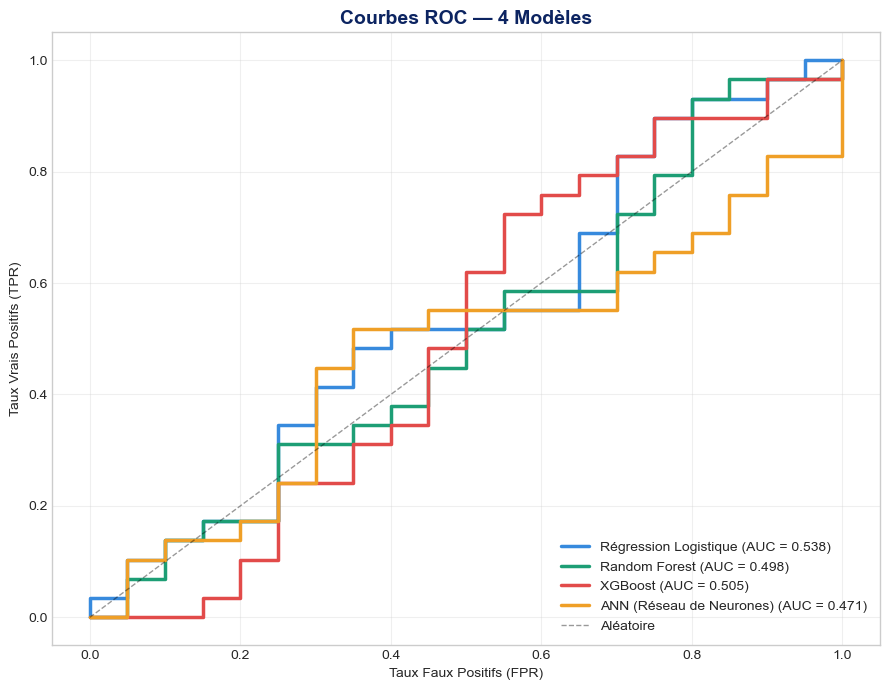

✅ Graphiques sauvegardés : 10_comparaison_4modeles.png + 11_roc_4modeles.png


In [28]:
# Graphique comparatif en barres groupées
fig, ax = plt.subplots(figsize=(16, 7))

metriques = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x         = np.arange(len(metriques))
width     = 0.2
colors_4  = ['#378ADD', '#1D9E75', '#E24B4A', '#EF9F27']

for i, (name, r) in enumerate(results.items()):
    vals = [r['accuracy'], r['precision'], r['recall'], r['f1'], r['auc']]
    bars = ax.bar(x + i*width, vals, width,
                  label=name, color=colors_4[i], edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

ax.set_xlabel('Métriques')
ax.set_ylabel('Score')
ax.set_title('Comparaison Finale — 4 Modèles', fontsize=14,
             fontweight='bold', color='#0C2461')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metriques)
ax.legend()
ax.set_ylim(0, 1.18)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('10_comparaison_4modeles.png', dpi=150, bbox_inches='tight')
plt.show()

# Courbes ROC
fig, ax = plt.subplots(figsize=(9, 7))
for (name, r), color in zip(results.items(), colors_4):
    y_reel = y_test_ann if name == 'ANN (Réseau de Neurones)' else y_test
    fpr, tpr, _ = roc_curve(y_reel, r['y_proba'])
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f"{name} (AUC = {r['auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Aléatoire')
ax.set_xlabel('Taux Faux Positifs (FPR)')
ax.set_ylabel('Taux Vrais Positifs (TPR)')
ax.set_title('Courbes ROC — 4 Modèles', fontsize=14,
             fontweight='bold', color='#0C2461')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('11_roc_4modeles.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Graphiques sauvegardés : 10_comparaison_4modeles.png + 11_roc_4modeles.png")


## 🏆 Section 7K — Sélection du Meilleur Modèle

### Pourquoi F1 + AUC et non R² ?

Le **R² (coefficient de détermination)** mesure la qualité d'une **régression** — prédire une valeur continue comme le MRR, le prix, ou la durée. Il n'a **aucun sens pour la classification**.

Ici on prédit `est_churn` (0 ou 1) → c'est une **classification binaire**. Les bonnes métriques sont :

| Métrique | Mesure | Usage |
|---|---|---|
| **F1-Score** | Équilibre Précision/Rappel | Idéal si classes déséquilibrées (peu de churns) |
| **AUC-ROC** | Capacité globale de discrimination | AUC=1 parfait, AUC=0.5 aléatoire |

### Score composite
Pour combiner les deux on calcule : **Score = 0.5 × F1 + 0.5 × AUC**
Le modèle avec le score le plus élevé devient le **meilleur modèle** retenu pour la production.


  CLASSEMENT FINAL DES MODÈLES
  🥇 1. Régression Logistique
       Score composite : 0.6219
       F1=0.7059 | AUC=0.5379 | Accuracy=0.5918
  🥈 2. ANN (Réseau de Neurones)
       Score composite : 0.5990
       F1=0.7273 | AUC=0.4707 | Accuracy=0.5714
  🥉 3. XGBoost
       Score composite : 0.5746
       F1=0.6441 | AUC=0.5052 | Accuracy=0.5714
     4. Random Forest
       Score composite : 0.5325
       F1=0.5667 | AUC=0.4983 | Accuracy=0.4694

  ✅ MEILLEUR MODÈLE : Régression Logistique
     Score composite (50% F1 + 50% AUC) : 0.6219


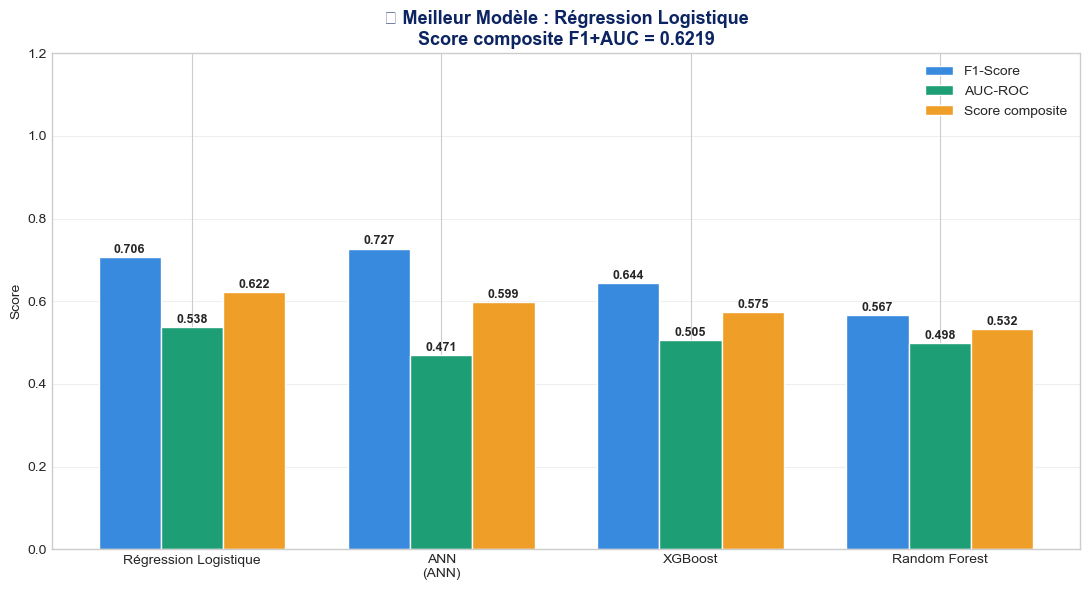


✅ best_name mis à jour : Régression Logistique


In [29]:
# Calcul du score composite
scores_composites = {
    name: (r['f1'] * 0.5 + r['auc'] * 0.5)
    for name, r in results.items()
}

meilleur_nom   = max(scores_composites, key=scores_composites.get)
meilleur_score = scores_composites[meilleur_nom]

# Classement
print("=" * 65)
print("  CLASSEMENT FINAL DES MODÈLES")
print("=" * 65)
classement = sorted(scores_composites.items(), key=lambda x: x[1], reverse=True)
for rang, (nom, score) in enumerate(classement, 1):
    r   = results[nom]
    tag = ["🥇", "🥈", "🥉", "  "][min(rang-1, 3)]
    print(f"  {tag} {rang}. {nom}")
    print(f"       Score composite : {score:.4f}")
    print(f"       F1={r['f1']:.4f} | AUC={r['auc']:.4f} | Accuracy={r['accuracy']:.4f}")
print("=" * 65)
print(f"\n  ✅ MEILLEUR MODÈLE : {meilleur_nom}")
print(f"     Score composite (50% F1 + 50% AUC) : {meilleur_score:.4f}")

# Graphique podium
fig, ax = plt.subplots(figsize=(11, 6))
noms_courts = [n.replace(' (Réseau de Neurones)', '\n(ANN)') for n,_ in classement]
f1_vals     = [results[n]['f1']  for n,_ in classement]
auc_vals    = [results[n]['auc'] for n,_ in classement]
sc_vals     = [s for _,s in classement]

x = np.arange(len(classement))
ax.bar(x - 0.25, f1_vals,  0.25, label='F1-Score',
       color='#378ADD', edgecolor='white')
ax.bar(x,        auc_vals, 0.25, label='AUC-ROC',
       color='#1D9E75', edgecolor='white')
ax.bar(x + 0.25, sc_vals,  0.25, label='Score composite',
       color='#EF9F27', edgecolor='white')

for i, (f1, auc, sc) in enumerate(zip(f1_vals, auc_vals, sc_vals)):
    ax.text(i-0.25, f1+0.01,  f'{f1:.3f}',  ha='center', fontsize=9, fontweight='bold')
    ax.text(i,      auc+0.01, f'{auc:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(i+0.25, sc+0.01,  f'{sc:.3f}',  ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(noms_courts, fontsize=10)
ax.set_ylabel('Score')
ax.set_title(f'🏆 Meilleur Modèle : {meilleur_nom}\n'
             f'Score composite F1+AUC = {meilleur_score:.4f}',
             fontsize=13, fontweight='bold', color='#0C2461')
ax.legend()
ax.set_ylim(0, 1.2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('12_meilleur_modele.png', dpi=150, bbox_inches='tight')
plt.show()

# Mettre à jour la variable best_name pour les sections suivantes
best_name = meilleur_nom
print(f"\n✅ best_name mis à jour : {best_name}")


## 📝 Section 8 — Rapport Automatisé

### Description
Cette section génère un **rapport textuel complet** qui synthétise :
- Les caractéristiques du dataset (taille, taux de churn, split)
- Les métriques de chacun des 3 modèles
- L'identification du meilleur modèle
- Les 5 features les plus importantes
- Une interprétation métier des résultats

Le rapport est sauvegardé dans `08_rapport_prediction.txt` pour être inclus  
dans un rapport PFE ou une présentation professionnelle.


In [30]:
# ── Calcul des top features pour le rapport ──────────────────────
if best_name == 'Régression Logistique':
    importances = np.abs(results[best_name]['model'].coef_[0])
else:
    importances = results[best_name]['model'].feature_importances_

top_features = pd.Series(importances, index=feature_cols) \
                  .sort_values(ascending=False).head(5)

# ── Construction du rapport ──────────────────────────────────────
rapport = f"""
{'='*70}
  RAPPORT DE PRÉDICTION DU CHURN — TOUIL NET
  Généré le : {datetime.now().strftime('%d/%m/%Y à %H:%M')}
{'='*70}

1. DONNÉES
   - Dataset          : {len(df)} utilisateurs
   - Features         : {len(feature_cols)} variables
   - Variable cible   : est_churn (0 = Non-churn | 1 = Churn)
   - Distribution     : {int(df['est_churn'].sum())} churns ({100*df['est_churn'].mean():.1f}%)
                        / {int(len(df)-df['est_churn'].sum())} non-churns ({100*(1-df['est_churn'].mean()):.1f}%)
   - Split            : Train {len(X_train)} ({100*len(X_train)/len(df):.0f}%)
                        | Test {len(X_test)} ({100*len(X_test)/len(df):.0f}%)

2. RÉSULTATS DES MODÈLES
"""

for name, r in results.items():
    rapport += f"""
   {name}
   {'─'*50}
   Accuracy  : {r['accuracy']:.4f}    Precision : {r['precision']:.4f}
   Recall    : {r['recall']:.4f}    F1-Score  : {r['f1']:.4f}
   AUC-ROC   : {r['auc']:.4f}    CV F1     : {r['cv_mean']:.4f} ± {r['cv_std']:.4f}
"""

rapport += f"""
3. MEILLEUR MODÈLE : {best_name}
   F1-Score : {results[best_name]['f1']:.4f}
   AUC-ROC  : {results[best_name]['auc']:.4f}

4. TOP 5 FEATURES LES PLUS IMPORTANTES
"""

for i, (feat, imp) in enumerate(top_features.items(), 1):
    rapport += f"   {i}. {feat} : {imp:.4f}\n"

rapport += f"""
5. INTERPRÉTATION MÉTIER
   Le modèle {best_name} offre les meilleures performances avec un
   F1-Score de {results[best_name]['f1']:.4f} et un AUC-ROC de {results[best_name]['auc']:.4f}.

   Les facteurs les plus déterminants pour prédire le churn sont :
   - {top_features.index[0]} (influence la plus forte)
   - {top_features.index[1]}
   - {top_features.index[2]}

   Ces résultats confirment que le comportement d'engagement (sessions,
   durée) et la satisfaction client (CSAT) sont des signaux prédictifs
   clés du risque de churn chez les abonnés SaaS de Touil Net.

6. FICHIERS GÉNÉRÉS
   - dataset_churn_enrichi.csv    → Dataset complet enrichi
   - 01_eda_churn.png             → Analyse exploratoire
   - 02_correlation_matrix.png    → Matrice de corrélation
   - 03_comparaison_modeles.csv   → Tableau comparatif des modèles
   - 04_courbes_roc.png           → Courbes ROC superposées
   - 05_matrices_confusion.png    → Matrices de confusion
   - 06_feature_importance.png    → Importance des features
   - 07_comparaison_barres.png    → Comparaison barres groupées
   - 08_rapport_prediction.txt    → Ce rapport
{'='*70}
"""

print(rapport)

# Sauvegarde du rapport
with open('08_rapport_prediction.txt', 'w', encoding='utf-8') as f:
    f.write(rapport)
print("\n✅ Rapport sauvegardé : 08_rapport_prediction.txt")



  RAPPORT DE PRÉDICTION DU CHURN — TOUIL NET
  Généré le : 07/06/2026 à 14:57

1. DONNÉES
   - Dataset          : 244 utilisateurs
   - Features         : 16 variables
   - Variable cible   : est_churn (0 = Non-churn | 1 = Churn)
   - Distribution     : 143 churns (58.6%)
                        / 101 non-churns (41.4%)
   - Split            : Train 195 (80%)
                        | Test 49 (20%)

2. RÉSULTATS DES MODÈLES

   Régression Logistique
   ──────────────────────────────────────────────────
   Accuracy  : 0.5918    Precision : 0.6154
   Recall    : 0.8276    F1-Score  : 0.7059
   AUC-ROC   : 0.5379    CV F1     : 0.6616 ± 0.0532

   Random Forest
   ──────────────────────────────────────────────────
   Accuracy  : 0.4694    Precision : 0.5484
   Recall    : 0.5862    F1-Score  : 0.5667
   AUC-ROC   : 0.4983    CV F1     : 0.6473 ± 0.0281

   XGBoost
   ──────────────────────────────────────────────────
   Accuracy  : 0.5714    Precision : 0.6333
   Recall    : 0.6552    F1

## ✅ Récapitulatif — Fichiers Générés

| Fichier | Description |
|---|---|
| `dataset_churn_enrichi.csv` | Dataset complet avec features dérivées |
| `01_eda_churn.png` | 6 graphiques d'analyse exploratoire |
| `02_correlation_matrix.png` | Matrice de corrélation des features |
| `03_comparaison_modeles.csv` | Tableau comparatif des 3 modèles |
| `04_courbes_roc.png` | Courbes ROC des 3 modèles superposées |
| `05_matrices_confusion.png` | Matrices de confusion côte à côte |
| `06_feature_importance.png` | Importance des variables (meilleur modèle) |
| `07_comparaison_barres.png` | Toutes les métriques en barres groupées |
| `08_rapport_prediction.txt` | Rapport textuel complet |

---
> 🎓 **Note PFE** : Les graphiques `01`, `02`, `04`, `05`, `06`, `07` sont directement utilisables dans un rapport académique ou une présentation.


In [31]:
print("=" * 60)
print("  ✅ PIPELINE TERMINÉ AVEC SUCCÈS !")
print("=" * 60)
print(f"  Meilleur modèle  : {best_name}")
print(f"  F1-Score         : {results[best_name]['f1']:.4f}")
print(f"  AUC-ROC          : {results[best_name]['auc']:.4f}")
print("=" * 60)


  ✅ PIPELINE TERMINÉ AVEC SUCCÈS !
  Meilleur modèle  : Régression Logistique
  F1-Score         : 0.7059
  AUC-ROC          : 0.5379
